In [2]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 67.0 MB/s eta 0:00:00:00:0100:01


In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn.functional as F
import timm
import faiss
from timm.data import resolve_model_data_config
from timm.data.transforms_factory import create_transform

device = "cuda" if torch.cuda.is_available() else "cpu"

manifest = pd.read_csv("/kaggle/input/datasets/karvysingh/ngaimggg/dataset_manifest.csv")

model = timm.create_model("vit_base_patch14_dinov2.lvd142m", pretrained=True, num_classes=0)
model.eval().to(device)

data_config = resolve_model_data_config(model)
transform = create_transform(**data_config, is_training=False)
BASE_PATH = "/kaggle/input/datasets/karvysingh/ngaimggg/images"

embeddings = []
for path in tqdm(manifest["image_path"]):
    full_path = f"{BASE_PATH}/{path.replace('./','')}"
    img = Image.open(full_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model(x)
        feat = F.normalize(feat, p=2, dim=1)
    embeddings.append(feat.cpu().numpy()[0])

embeddings = np.array(embeddings).astype("float32")
np.save("/kaggle/working/embeddings.npy", embeddings)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
faiss.write_index(index, "/kaggle/working/paintings.faiss")

print("done", embeddings.shape, index.ntotal)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  0%|          | 3/5802 [00:08<4:46:05,  2.96s/it]

manifest: (5802, 10)
embeddings: (5802, 768)
faiss index size: 5802


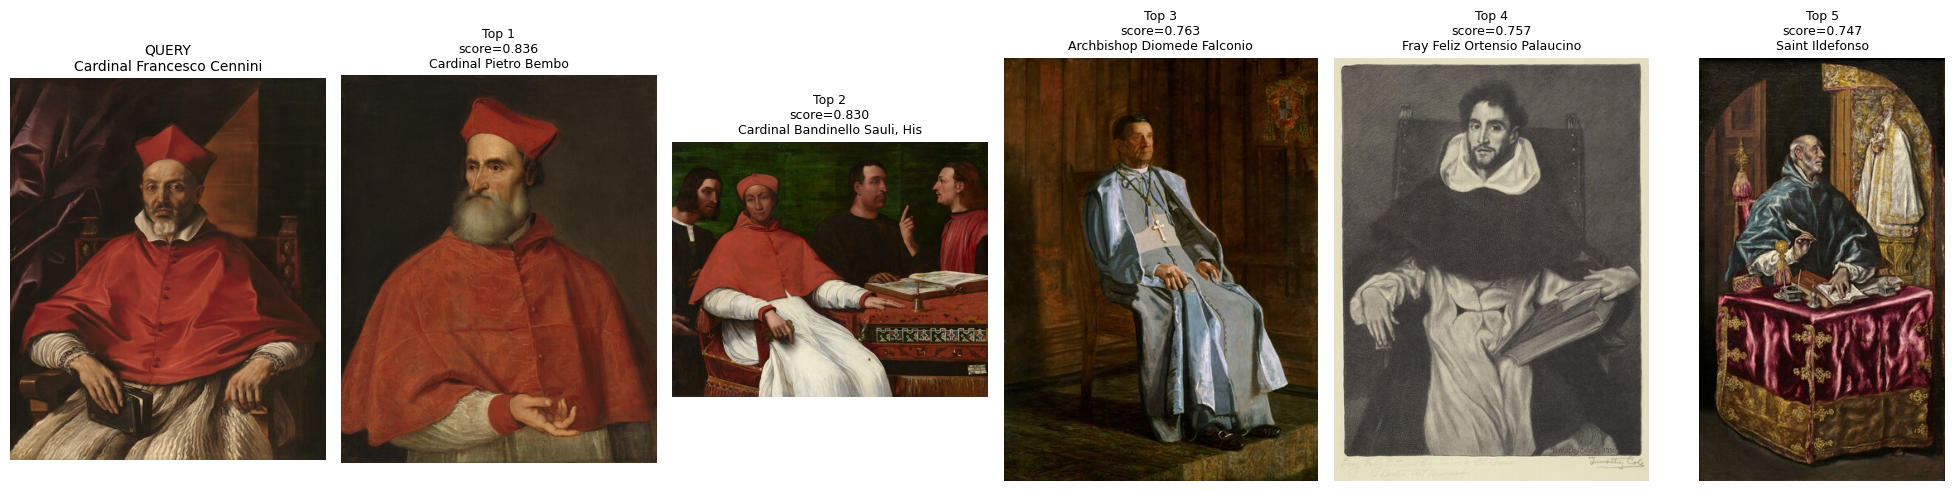

,rank,idx,score,objectid,title,classification,dated,artist
0,1,1027,0.8357,41638,Cardinal Pietro Bembo,painting,NaN,NaN
1,2,2521,0.8303,46136,"Cardinal Bandinello Sauli, His Secretary, and ...",painting,NaN,NaN
2,3,1916,0.7629,33250,Archbishop Diomede Falconio,painting,NaN,NaN
3,4,4288,0.7566,57970,Fray Feliz Ortensio Palaucino,print,NaN,NaN
4,5,49,0.7466,90,Saint Ildefonso,painting,NaN,NaN


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import faiss

MANIFEST_PATH = "/kaggle/input/datasets/karvysingh/ngaimggg/dataset_manifest.csv"
EMBEDDINGS_PATH = "/kaggle/input/datasets/karvysingh/embeddingss/embeddings (1).npy"
FAISS_PATH = "/kaggle/input/datasets/karvysingh/embeddingss/paintings (1).faiss"
BASE_PATH = "/kaggle/input/datasets/karvysingh/ngaimggg/images"

manifest = pd.read_csv(MANIFEST_PATH)
embeddings = np.load(EMBEDDINGS_PATH).astype("float32")
index = faiss.read_index(FAISS_PATH)

print("manifest:", manifest.shape)
print("embeddings:", embeddings.shape)
print("faiss index size:", index.ntotal)

def get_full_image_path(rel_path):
    rel_path = str(rel_path).replace("./", "").replace("\\", "/")
    return os.path.join(BASE_PATH, rel_path)

def retrieve_similar(query_idx, k=5):
    query_vec = embeddings[query_idx:query_idx+1]
    scores, indices = index.search(query_vec, k + 1)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == query_idx:
            continue
        results.append((int(idx), float(score)))
        if len(results) == k:
            break
    return results


def show_results(query_idx, k=5, figsize=(20, 5)):
    query_row = manifest.iloc[query_idx]
    query_img_path = get_full_image_path(query_row["image_path"])

    results = retrieve_similar(query_idx, k=k)

    fig, axes = plt.subplots(1, k + 1, figsize=figsize)

    # query image
    query_img = Image.open(query_img_path).convert("RGB")
    axes[0].imshow(query_img)
    axes[0].axis("off")
    axes[0].set_title(
        f"QUERY\n{str(query_row.get('title', ''))[:35]}",
        fontsize=10
    )

    # retrieved images
    for i, (idx, score) in enumerate(results, start=1):
        row = manifest.iloc[idx]
        img_path = get_full_image_path(row["image_path"])
        img = Image.open(img_path).convert("RGB")

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(
            f"Top {i}\nscore={score:.3f}\n{str(row.get('title', ''))[:30]}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    rows = []
    for rank, (idx, score) in enumerate(results, start=1):
        row = manifest.iloc[idx]
        rows.append({
            "rank": rank,
            "idx": idx,
            "score": round(score, 4),
            "objectid": row.get("objectid", ""),
            "title": row.get("title", ""),
            "classification": row.get("classification", ""),
            "dated": row.get("dated", ""),
            "artist": row.get("artist", "")
        })

    return pd.DataFrame(rows)

show_results(query_idx=0, k=5)

In [4]:
import os
import cv2
import timm
import torch
import numpy as np
import torch.nn.functional as F

from PIL import Image
from functools import lru_cache
from torchvision import transforms

import timm
import torch
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "vit_base_patch14_dinov2.lvd142m",
    pretrained=True,
    num_classes=0
).to(device)
model.eval()

data_config = resolve_data_config({}, model=model)
transform = create_transform(**data_config, is_training=False)

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# --------------------------------------------------
# checks
# --------------------------------------------------
required_vars = ["manifest", "embeddings", "index", "get_full_image_path"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(
        f"Missing required objects: {missing}. "
        "You need manifest, embeddings, index, and get_full_image_path first."
    )

# --------------------------------------------------
# helpers
# --------------------------------------------------
def cosine(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

@lru_cache(maxsize=None)
def load_pil(idx):
    path = get_full_image_path(manifest.iloc[idx]["image_path"])
    return Image.open(path).convert("RGB")

@lru_cache(maxsize=None)
def detect_face_box(idx):
    img = np.array(load_pil(idx))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40)
    )

    if len(faces) == 0:
        return None

    x, y, w, h = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)[0]
    H, W = gray.shape

    return {
        "box": (int(x), int(y), int(w), int(h)),
        "center_x": float((x + w / 2) / W),
        "center_y": float((y + h / 2) / H),
        "area_ratio": float((w * h) / (W * H)),
        "aspect_ratio": float(w / max(h, 1))
    }

def get_embedding_from_pil(img):
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model(x)
        if feat.ndim == 1:
            feat = feat.unsqueeze(0)
        feat = F.normalize(feat, p=2, dim=1)
    return feat.cpu().numpy()[0].astype("float32")

@lru_cache(maxsize=None)
def global_embedding(idx):
    return get_embedding_from_pil(load_pil(idx))

@lru_cache(maxsize=None)
def face_embedding(idx):
    face = detect_face_box(idx)
    if face is None:
        return None

    x, y, w, h = face["box"]
    img = load_pil(idx)

    pad = int(0.2 * max(w, h))
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(img.width, x + w + pad)
    y2 = min(img.height, y + h + pad)

    crop = img.crop((x1, y1, x2, y2))
    return get_embedding_from_pil(crop)

def pose_score(i, j):
    fi = detect_face_box(i)
    fj = detect_face_box(j)

    if fi is None or fj is None:
        return 0.0

    dx = abs(fi["center_x"] - fj["center_x"])
    dy = abs(fi["center_y"] - fj["center_y"])
    ds = abs(fi["area_ratio"] - fj["area_ratio"])
    da = abs(fi["aspect_ratio"] - fj["aspect_ratio"])

    score = 1.0 - (0.35 * dx + 0.20 * dy + 0.25 * ds + 0.20 * min(da, 1.0))
    return float(max(0.0, score))

def composition_score(i, j):
    fi = detect_face_box(i)
    fj = detect_face_box(j)

    if fi is not None and fj is not None:
        dx = abs(fi["center_x"] - fj["center_x"])
        dy = abs(fi["center_y"] - fj["center_y"])
        ds = abs(fi["area_ratio"] - fj["area_ratio"])
        score = 1.0 - (0.4 * dx + 0.3 * dy + 0.3 * ds)
        return float(max(0.0, score))

    return cosine(embeddings[i], embeddings[j])

def metadata_score(i, j):
    row_i = manifest.iloc[i]
    row_j = manifest.iloc[j]

    field_groups = [
        ["artist", "artist_name", "attribution"],
        ["classification", "object_type", "type"],
        ["style", "school"],
        ["medium", "technique"],
        ["date", "display_date", "year"]
    ]

    score = 0.0
    used = 0

    for group in field_groups:
        found = None
        for col in group:
            if col in manifest.columns:
                found = col
                break

        if found is None:
            continue

        a = str(row_i[found]).strip().lower()
        b = str(row_j[found]).strip().lower()

        if a and b and a != "nan" and b != "nan":
            used += 1
            if a == b:
                score += 1.0

    if used == 0:
        return 0.0
    return float(score / used)

# --------------------------------------------------
# reranking
# --------------------------------------------------
def rerank_candidates(query_idx, candidate_indices):
    q_face = detect_face_box(query_idx)
    q_face_emb = face_embedding(query_idx)

    scored = []

    for idx in candidate_indices:
        idx = int(idx)
        base = cosine(embeddings[query_idx], embeddings[idx])

        c_face = detect_face_box(idx)

        if q_face is not None and c_face is not None:
            c_face_emb = face_embedding(idx)
            face_sim = cosine(q_face_emb, c_face_emb) if (q_face_emb is not None and c_face_emb is not None) else 0.0
            pose_sim = pose_score(query_idx, idx)
            comp_sim = composition_score(query_idx, idx)
            meta_sim = metadata_score(query_idx, idx)

            final = (
                0.45 * base +
                0.25 * face_sim +
                0.15 * pose_sim +
                0.10 * comp_sim +
                0.05 * meta_sim
            )
        else:
            comp_sim = composition_score(query_idx, idx)
            meta_sim = metadata_score(query_idx, idx)

            final = (
                0.80 * base +
                0.15 * comp_sim +
                0.05 * meta_sim
            )

        scored.append((idx, float(final)))

    scored.sort(key=lambda x: x[1], reverse=True)
    return scored

def retrieve_similar_reranked(query_idx, first_k=30, final_k=5):
    query_vec = np.asarray(embeddings[query_idx:query_idx + 1]).astype("float32")
    scores, indices = index.search(query_vec, first_k + 1)

    candidates = []
    for idx in indices[0]:
        idx = int(idx)
        if idx != query_idx:
            candidates.append(idx)

    reranked = rerank_candidates(query_idx, candidates)
    return reranked[:final_k]

# --------------------------------------------------
# optional display
# --------------------------------------------------
def show_reranked_results(query_idx, first_k=30, final_k=5):
    import matplotlib.pyplot as plt

    results = retrieve_similar_reranked(query_idx, first_k=first_k, final_k=final_k)

    fig, axes = plt.subplots(1, final_k + 1, figsize=(4 * (final_k + 1), 4))

    axes[0].imshow(load_pil(query_idx))
    axes[0].set_title(f"Query\nidx={query_idx}")
    axes[0].axis("off")

    for k, (idx, score) in enumerate(results, start=1):
        axes[k].imshow(load_pil(idx))
        axes[k].set_title(f"Rank {k}\nidx={idx}\nscore={score:.3f}")
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()

    return results

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

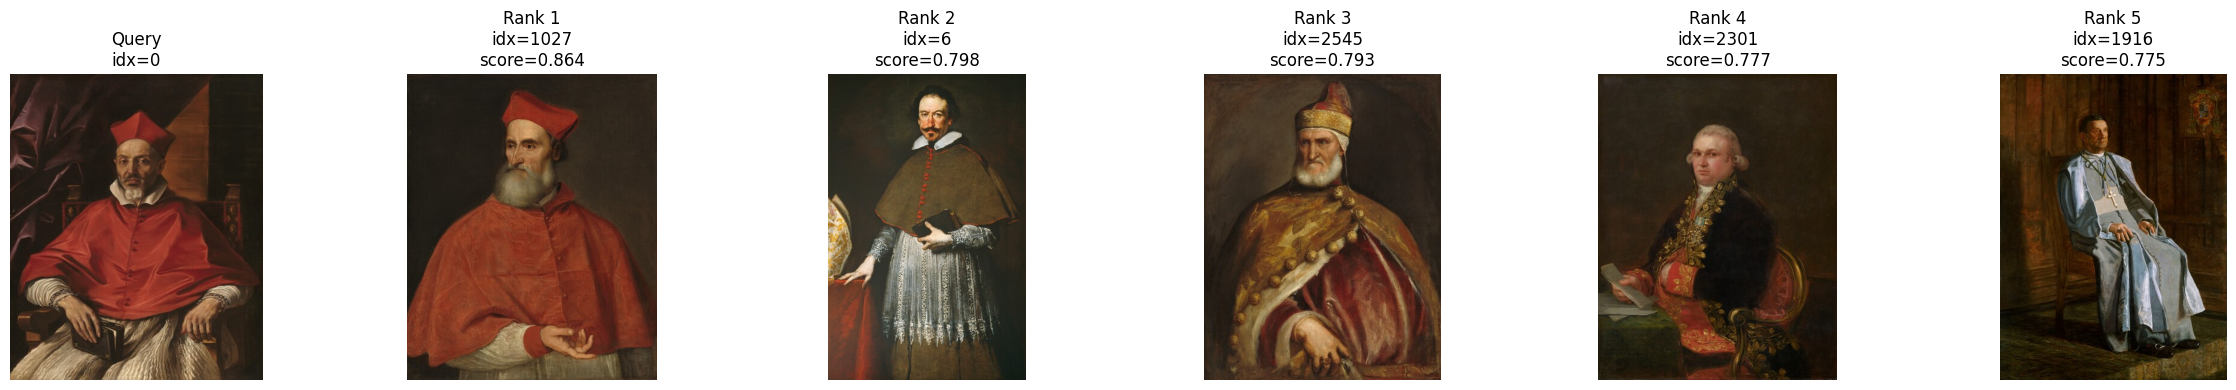

[(1027, 0.8639294697856924),
 (6, 0.7976009214831865),
 (2545, 0.7929791233544962),
 (2301, 0.7770967489832293),
 (1916, 0.7747384041547776)]

In [5]:
show_reranked_results(query_idx=0, first_k=30, final_k=5)

In [6]:
# minimal evaluation on retrieved samples
# uses manifest["classification"] as ground truth label
# change label_col if you want artist/title/etc.

import numpy as np

label_col = "classification"
k = 5

valid = manifest[label_col].notna() & (manifest[label_col].astype(str).str.strip() != "")
query_indices = np.where(valid)[0]

def evaluate_retrieval(get_results_fn, query_indices, label_col="classification", k=5):
    hits = 0
    precisions = []
    aps = []

    for q in query_indices:
        true_label = str(manifest.iloc[q][label_col]).strip().lower()

        results = get_results_fn(q, k)
        retrieved_idxs = [idx for idx, _ in results[:k]]

        retrieved_labels = [
            str(manifest.iloc[idx][label_col]).strip().lower()
            for idx in retrieved_idxs
        ]

        correct = np.array([lbl == true_label for lbl in retrieved_labels], dtype=bool)

        hits += correct.any()
        precisions.append(correct.mean())

        cumsum = np.cumsum(correct)
        ranks = np.arange(1, len(correct) + 1)
        ap = ((cumsum / ranks) * correct).sum() / correct.sum() if correct.sum() > 0 else 0.0
        aps.append(ap)

    print(f"Queries: {len(query_indices)}")
    print(f"Recall@{k}: {hits / len(query_indices):.4f}")
    print(f"Precision@{k}: {np.mean(precisions):.4f}")
    print(f"mAP@{k}: {np.mean(aps):.4f}")

# base faiss retrieval
evaluate_retrieval(
    lambda q, k: retrieve_similar(q, k=k),
    query_indices,
    label_col=label_col,
    k=k
)

evaluate_retrieval(
    lambda q, k: retrieve_similar_reranked(q, first_k=30, final_k=k),
    query_indices[:300],
    label_col=label_col,
    k=k
)

Queries: 5802
Recall@5: 0.9600
Precision@5: 0.7451
mAP@5: 0.8309
Queries: 300
Recall@5: 0.9967
Precision@5: 0.9320
mAP@5: 0.9583
